In [21]:
import h5py
import pygmt
import numpy as np
import xarray as xr


In [22]:
with h5py.File('OUTPUT_FILES/initial_model.h5', 'r') as f:
    vs = f['vs'][:]
    x = f['x'][:]
    y = f['y'][:]
    z = f['z'][:]

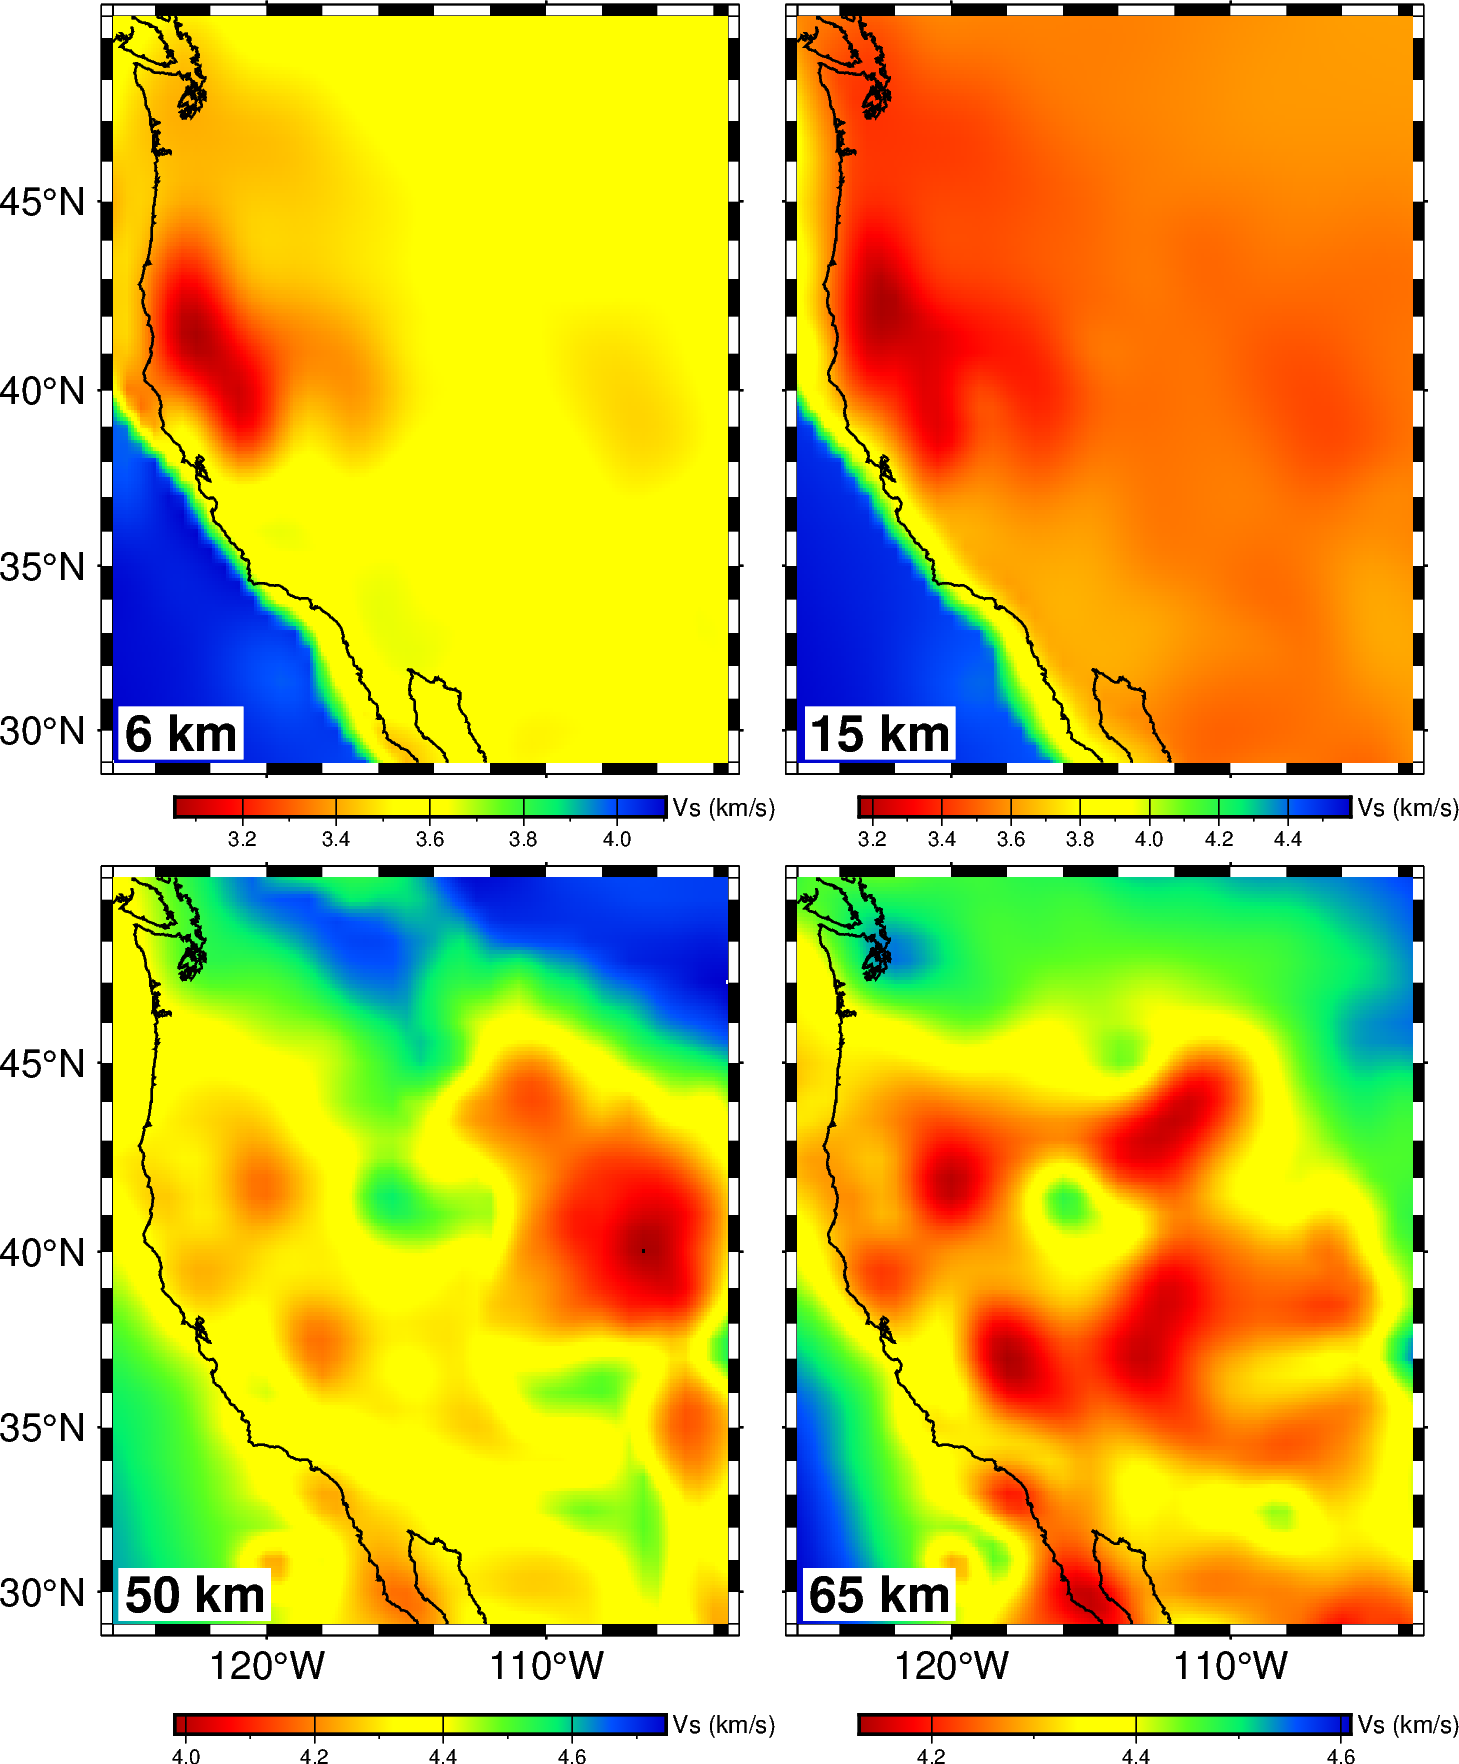

In [52]:
dep = [6, 15, 50, 65]

fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=2, figsize=(11, 14),
            sharex="b", sharey="l"):
    for i, d in enumerate(dep):
        iz = np.argmin(np.abs(z - d))
        grid = xr.DataArray(vs[:, :, iz].T, dims=["y", "x"], coords={"y": y, "x": x})
        fig.basemap(region=[x.min(), x.max(), y.min(), y.max()], projection="M?", frame=["xaf", "yaf"], panel=i)
        vmax = np.max(vs[:, :, iz])
        vmin = np.min(vs[:, :, iz])
        pygmt.makecpt(cmap="seis", series=[vmin, vmax])
        fig.grdimage(grid, cmap=True)
        fig.coast(shorelines="0.5p,black", area_thresh=10000)
        # fig.grdcontour(grid, interval=0.2, pen="0.5p,black")
        fig.text(position="BL", text=f"{d} km", font="12p,Helvetica-Bold,black", fill='255', offset="0.1c/0.1c")
        fig.colorbar(frame=['a0.2f0.1g0.2', 'y+lVs (km/s)'])
fig.show()
